In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
df = pd.read_csv("dataset.csv")

df.head()

,fever,headache,cough,fatigue,body pain,sore throat,chest pain,shortness of breath,vomiting,diarrhea,...,ear pain,eye redness,blurred vision,palpitations,anxiety,loss of appetite,weight loss,swelling,dry mouth,disease
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
2,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
4,1,0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu


In [3]:
print("Dataset shape:", df.shape)
print("\nDisease counts:")
print(df["disease"].value_counts())

Dataset shape: (360, 31)

Disease counts:
disease
Flu                        20
Common Cold                20
COVID-19                   20
Migraine                   20
Food Poisoning             20
Gastritis                  20
Respiratory Issue          20
Allergy                    20
Urinary Tract Infection    20
Joint Inflammation         20
Asthma                     20
Bronchitis                 20
Pneumonia                  20
Eczema                     20
Skin Infection             20
Vertigo                    20
Possible Cardiac Issue     20
Kidney Stone               20
Name: count, dtype: int64


In [4]:
X = df.drop("disease", axis=1)
y = df["disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (360, 30)
Target shape: (360,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (288, 30)
Testing size: (72, 30)


In [6]:
lr_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [7]:
y_pred = lr_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Logistic Regression Results
---------------------------
Accuracy: 0.7083
Precision: 0.6944
Recall: 0.7083
F1-score: 0.6869


In [9]:
print(classification_report(y_test, y_pred, zero_division=0))

                         precision    recall  f1-score   support

                Allergy       0.75      0.75      0.75         4
                 Asthma       0.60      0.75      0.67         4
             Bronchitis       0.00      0.00      0.00         4
               COVID-19       0.33      0.25      0.29         4
            Common Cold       1.00      0.50      0.67         4
                 Eczema       1.00      1.00      1.00         4
                    Flu       0.60      0.75      0.67         4
         Food Poisoning       1.00      1.00      1.00         4
              Gastritis       1.00      1.00      1.00         4
     Joint Inflammation       1.00      1.00      1.00         4
           Kidney Stone       0.67      1.00      0.80         4
               Migraine       0.80      1.00      0.89         4
              Pneumonia       0.60      0.75      0.67         4
 Possible Cardiac Issue       0.60      0.75      0.67         4
      Respiratory Issue 

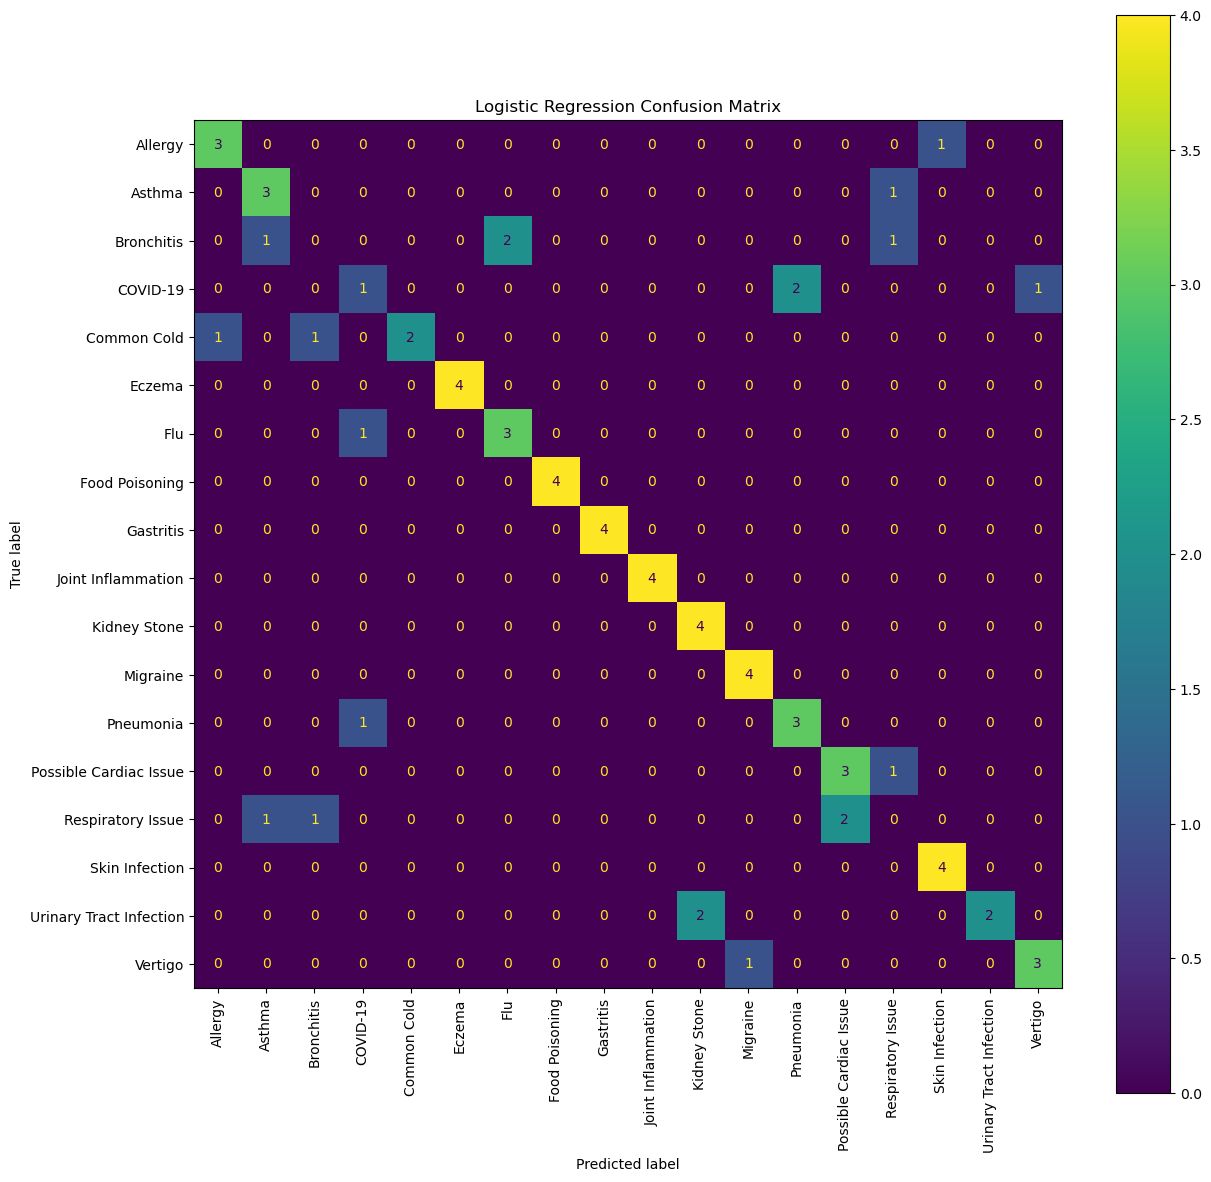

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [11]:
logistic_regression_results = {
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4)
}

logistic_regression_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7083,
 'Precision': 0.6944,
 'Recall': 0.7083,
 'F1-score': 0.6869}